# 1. Setup and Authentication
In this notebook, we download the historical data from Hopsworks, finetune and train three different models, and upload the best one to the Model Registry.

In [1]:
!pip install -q hopsworks pandas numpy scikit-learn xgboost shap matplotlib seaborn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.8/815.8 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.6/258.6 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 102.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 85.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 6.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following depe

In [2]:
import pandas as pd
import numpy as np
import hopsworks
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
import shap
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Log in to Hopsworks
project = hopsworks.login()
fs = project.get_feature_store()

Copy your API Key (first register/login at https://run.hopsworks.ai)



Paste it here:  ········


2026-06-06 19:17:55,259 INFO: Initializing external client
2026-06-06 19:17:55,259 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443


2026-06-06 19:18:00,332 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/33087


# 2. Fetch Data from Feature Store

In [4]:
try:
    aqi_fg = fs.get_feature_group(name="aqi_features", version=1)
    query = aqi_fg.select_all()
    feature_view = fs.get_or_create_feature_view(
        name="aqi_features_view",
        version=2,
        description="Read from AQI feature group",
        labels=["target_aqi_24h", "target_aqi_48h", "target_aqi_72h"],
        query=query
    )
    X, y = feature_view.training_data(description="Training data for AQI prediction")
except Exception as e:
    print("Error retrieving feature view. Ensure Notebook 1 was executed properly.")


Feature view created successfully, explore it at 
https://eu-west.cloud.hopsworks.ai:443/p/33087/fs/21771/fv/aqi_features_view/version/2
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (3.99s) 
2026-06-06 19:18:21,162 INFO: Computing insert statistics


# 3. Data Preparation
We drop the 24h and 48h targets since we are only predicting the 72h target.

In [5]:
X = X.drop(['date', 'timestamp', 'target_aqi_24h', 'target_aqi_48h', 'target_aqi_72h'], axis=1, errors='ignore')
X.sort_index(inplace=True)
y.sort_index(inplace=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (23961, 18), Test size: (5991, 18)


# 4. Hyperparameter Tuning & Model Training
We define a parameter grid for each model and use `RandomizedSearchCV` to find the best configuration.

In [7]:
# Define base models
models = {
    "Ridge Regression": Ridge(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}

# Define hyperparameter grids
param_grids = {
    "Ridge Regression": {
        'alpha': [0.1, 1.0, 10.0, 100.0]
    },
    "Random Forest": {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10]
    },
    "XGBoost": {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7, 9],
        'subsample': [0.8, 1.0]
    }
}

results = {}
best_overall_r2 = -float('inf')
best_overall_model_name = None
best_overall_model = None

for name, model in models.items():
    print(f"--- Tuning and Training {name} ---")
    grid = param_grids[name]
    
    # We use RandomizedSearchCV for speed. For Ridge, it's small enough to exhaust quickly.
    search = RandomizedSearchCV(
        model, param_distributions=grid, n_iter=10, cv=3, 
        scoring='r2', n_jobs=-1, random_state=42, verbose=1
    )
    
    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    
    print(f"Best params for {name}: {search.best_params_}")
    
    preds = best_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'Model': best_model}
    print(f"{name} Test Metrics -> RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}\n")
    
    if r2 > best_overall_r2:
        best_overall_r2 = r2
        best_overall_model_name = name
        best_overall_model = best_model

print(f"\n🏆 *** Best Overall Model: {best_overall_model_name} with Test R2: {best_overall_r2:.2f} ***")

--- Tuning and Training Ridge Regression ---
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best params for Ridge Regression: {'alpha': 1.0}
Ridge Regression Test Metrics -> RMSE: 20.70, MAE: 14.59, R2: 0.49

--- Tuning and Training Random Forest ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params for Random Forest: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 30}
Random Forest Test Metrics -> RMSE: 12.22, MAE: 7.68, R2: 0.82

--- Tuning and Training XGBoost ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params for XGBoost: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.1}
XGBoost Test Metrics -> RMSE: 11.17, MAE: 7.16, R2: 0.85


🏆 *** Best Overall Model: XGBoost with Test R2: 0.85 ***


# 5. SHAP Analysis
Compute SHAP values for the best model to understand feature importance.

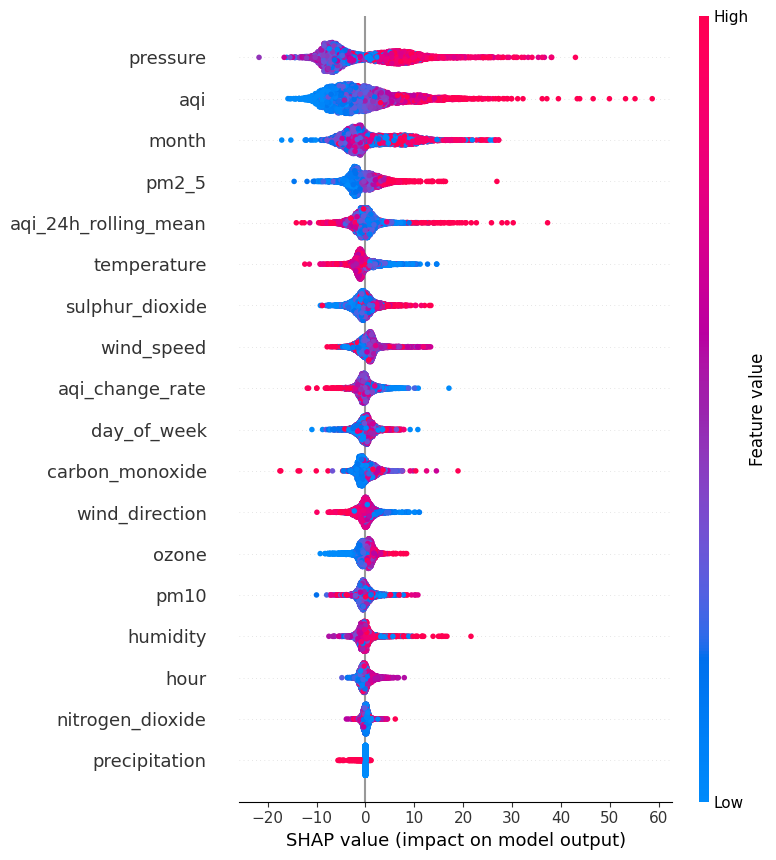

In [8]:
if best_overall_model_name in ["Random Forest", "XGBoost"]:
    explainer = shap.TreeExplainer(best_overall_model)
else:
    explainer = shap.LinearExplainer(best_overall_model, X_train)

shap_values = explainer.shap_values(X_test)
if isinstance(shap_values, list):
    shap_values_plot = shap_values[2]
elif len(shap_values.shape) == 3:
    shap_values_plot = shap_values[:, :, 2]
else:
    shap_values_plot = shap_values
shap.summary_plot(shap_values_plot, X_test, show=False)
import matplotlib.pyplot as plt
plt.savefig("shap_summary.png", bbox_inches='tight')


# 6. Upload Best Model to Hopsworks

In [9]:
mr = project.get_model_registry()

model_dir = "aqi_model_dir"
if not os.path.exists(model_dir):
    os.mkdir(model_dir)

model_path = os.path.join(model_dir, "aqi_model.pkl")
joblib.dump(best_overall_model, model_path)
explainer_path = os.path.join(model_dir, "shap_explainer.pkl")
joblib.dump(explainer, explainer_path)

# Create performance metrics dictionary
metrics = {
    "RMSE": results[best_overall_model_name]['RMSE'],
    "MAE": results[best_overall_model_name]['MAE'],
    "R2": results[best_overall_model_name]['R2']
}

aqi_model = mr.python.create_model(
    name="aqi_prediction_model",
    metrics=metrics,
    model_schema=None, # Optional schema
    description=f"AQI prediction model using tuned {best_overall_model_name}"
)

aqi_model.save(model_dir)
print("Model successfully uploaded to Hopsworks!")

  0%|          | 0/6 [00:00<?, ?it/s]

Moving model files from 'aqi_model_dir' to the model registry... This is the default behavior. Set keep_original_files=True to copy files instead.


Uploading /kaggle/working/aqi_model_dir/shap_explainer.pkl: 0.000%|          | 0/59489254 elapsed<00:00 remain…

Uploading /kaggle/working/aqi_model_dir/aqi_model.pkl: 0.000%|          | 0/13138323 elapsed<00:00 remaining<?

Model created, explore it at https://eu-west.cloud.hopsworks.ai:443/p/33087/models/aqi_prediction_model/2
Model successfully uploaded to Hopsworks!
